In [1]:
import os
os.environ["NUMBA_DISABLE_JIT"] = "1"
os.environ["NUMBA_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
print("Pinned threads + disabled numba JIT")

Pinned threads + disabled numba JIT


In [24]:
from prompt import Prompt

In [21]:
prompt = Prompt(
    components=("jet",),            # just jet for now
    sample_gw_parameters=False,     # we will pass theta_los
    gw_param_mode="mass",           # so _extract_masses expects mass_1/mass_2
    j_struct="tophat",            # or 1/2/3
    eta_jet=1e-4,
    frac=0.1,
    phi_los_deg=0.0,
    default_theta_los_deg=0.0,
)

prompt.check_print()

params = {
    # jet knobs

    # viewing angle
    "theta_los": 30.0,         # degrees

    # binary / EOS inputs used in _derive_Eiso_jet
    "mass_1": 1.8,             # Msun
    "mass_2": 1.4,             # Msun
    "lambda_2": 300.0,         # dimensionless tidal deformability
}

import sys
print("CELL START")
sys.stdout.flush()

out = prompt.update_model(params, dry_run=False)

print("CELL END", out)
sys.stdout.flush()

x = [i*i for i in range(10_000_000)]
sum(x)

Object OK!
CELL START
Updating model...
eisojet val 1.1403765767974741e+49
Jet Constructed Successfully...
CELL END None


333333283333335000000

In [22]:
test2 = prompt.total_X

In [5]:
prompt = Prompt(
    components=("jet",),            # just jet for now
    sample_gw_parameters=False,     # we will pass theta_los
    gw_param_mode="mass",           # so _extract_masses expects mass_1/mass_2
    j_struct="tophat",            # or 1/2/3
    eta_jet=1e-4,
    frac=0.1,
    phi_los_deg=0.0,
    default_theta_los_deg=0.0,
)

prompt.check_print()

params = {
    # jet knobs

    # viewing angle
    "theta_los": 0.0,         # degrees

    # binary / EOS inputs used in _derive_Eiso_jet
    "mass_1": 1.8,             # Msun
    "mass_2": 1.4,             # Msun
    "lambda_2": 300.0,         # dimensionless tidal deformability
}

Object OK!


In [6]:
%%time
import sys
print("CELL START")
sys.stdout.flush()

out = prompt.update_model(params, dry_run=False)

print("CELL END", out)
sys.stdout.flush()

x = [i*i for i in range(10_000_000)]
sum(x)

CELL START
Updating model...
eisojet val 1.1403765767974741e+49
Jet Constructed Successfully...
CELL END None
CPU times: user 8.59 s, sys: 9.84 s, total: 18.4 s
Wall time: 6.4 s


333333283333335000000

In [7]:
test1 = prompt.total_X

In [6]:
# predict_lightcurve.py
import numpy as np
import torch
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "lightcurve_mlp.pt"

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

class LightCurveMLP(nn.Module):
    def __init__(self, in_dim=4, out_dim=1000, hidden=512, depth=4, dropout=0.05):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.GELU()]
        for _ in range(depth):
            layers.append(ResidualBlock(hidden, dropout=dropout))
        layers += [nn.Dropout(dropout), nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def load_model(model_path=MODEL_PATH):
    ckpt = torch.load(model_path, map_location=DEVICE)

    out_dim = ckpt["y_mean"].shape[1]
    hidden = ckpt["config"]["hidden"]
    depth = ckpt["config"]["depth"]
    dropout = ckpt["config"]["dropout"]

    model = LightCurveMLP(
        in_dim=4,
        out_dim=out_dim,
        hidden=hidden,
        depth=depth,
        dropout=dropout,
    ).to(DEVICE)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model, ckpt

def predict(params_4):
    """
    params_4: array-like shape (4,) or (N,4)
    Returns predicted light curve(s) in ORIGINAL log-space.
    """
    model, ckpt = load_model()

    x = np.asarray(params_4, dtype=np.float32)
    if x.ndim == 1:
        x = x[None, :]
    assert x.shape[1] == 4, f"Expected shape (N,4), got {x.shape}"

    x_mean = ckpt["x_mean"]
    x_std = ckpt["x_std"]
    y_mean = ckpt["y_mean"]
    y_std = ckpt["y_std"]
    t_grid = ckpt["t_grid"]

    xn = (x - x_mean) / x_std
    xt = torch.from_numpy(xn).to(DEVICE)

    with torch.no_grad():
        yn_pred = model(xt).cpu().numpy()

    y_pred = yn_pred * y_std + y_mean   # back to original log-space
    return t_grid, y_pred

if __name__ == "__main__":
    # Example
    example_params = [0.0, 0.0, 0.0, 0.0]
    t, y = predict(example_params)
    print("t_grid shape:", t.shape)
    print("predicted curve shape:", y.shape)

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray._reconstruct was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray._reconstruct])` or the `torch.serialization.safe_globals([numpy._core.multiarray._reconstruct])` context manager to allowlist this global if you trust this class/function.

Check the documentation of to

In [25]:
prompt = Prompt(
    components=("jet",),            # just jet for now
    sample_gw_parameters=False,     # we will pass theta_los
    gw_param_mode="mass",           # so _extract_masses expects mass_1/mass_2
    j_struct="tophat",            # or 1/2/3
    eta=1e-4,
    frac=0.1,
    phi_los_deg=0.0,
    default_theta_los_deg=0.0,
)

prompt.check_print()

params = {
    # jet knobs
    "gamma_jet": 100.0,
    "theta_c_jet": 5.0,        # degrees
    "theta_cut_jet": 35.0,     # degrees

    # viewing angle
    "theta_los": 30,         # degrees

    # binary / EOS inputs used in _derive_Eiso_jet
    "mass_1": 1.8,             # Msun
    "mass_2": 1.4,             # Msun
    "lambda_2": 300.0,         # dimensionless tidal deformability
}

Object OK!


In [26]:
%%time
import sys
print("CELL START")
sys.stdout.flush()

out = prompt.update_model(params, dry_run=False)

print("CELL END", out)
sys.stdout.flush()

x = [i*i for i in range(10_000_000)]
sum(x)

CELL START
Updating model...
Jet Constructed Successfully...
CELL END None
CPU times: user 8.7 s, sys: 10 s, total: 18.7 s
Wall time: 6.5 s


333333283333335000000

In [27]:
test2 = prompt.total_X

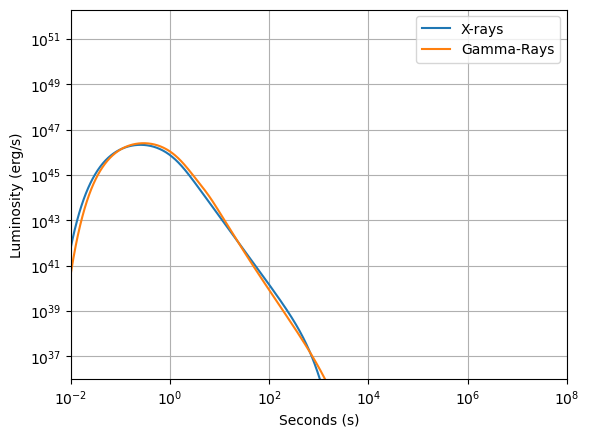

In [28]:
import matplotlib.pyplot as plt

plt.plot(prompt.t, test1, label = 'X-rays')
plt.plot(prompt.t, test2, label = 'Gamma-Rays')
plt.xlim([1e-2, 1e8])
plt.ylim([1e36, 2e52])
plt.ylabel('Luminosity (erg/s)')
plt.xlabel('Seconds (s)')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.legend()
plt.show()

In [55]:
#FLUX RUN

prompt2 = Prompt(
    components=("jet",),
    sample_gw_parameters=False,
    gw_param_mode="mass",
    j_struct="tophat",
    use_disk_mass_mapping=True,
    output="flux",
    default_distance_mpc=40.0,   # will be overridden by params if provided
)

params_base = {
    "gamma_jet": 300.0,
    "theta_c_jet": 5.0,
    "theta_cut_jet": 30.0,
    "theta_los": 0.0,
    "mass_1": 1.4,
    "mass_2": 1.2,
    "lambda_2": 300.0,
}

# Run at D=100 Mpc
params_100 = dict(params_base)
params_100["luminosity_distance"] = 100.0
prompt2.update_model(params_100, dry_run=False)

Updating model...
Jet Constructed Successfully...


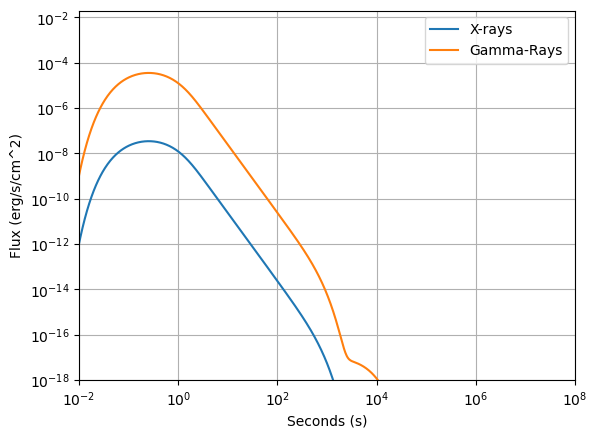

In [76]:
import matplotlib.pyplot as plt

plt.plot(prompt2.t, prompt2.total_X, label = 'X-rays')
plt.plot(prompt2.t, prompt2.total_gamma, label = 'Gamma-Rays')
plt.xlim([1e-2, 1e8])
plt.ylim([1e-18, 2e-2])
plt.ylabel('Flux (erg/s/cm^2)')
plt.xlabel('Seconds (s)')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.legend()
plt.show()

In [57]:
import numpy as np

frac = 0.1
seed = 42
floor = 0 #set 2e40 for more realistic instrument floor

rng = np.random.default_rng(seed)
sigma = frac * np.abs(prompt.total_X) + float(floor)
sim_data = prompt.total_X + rng.normal(0.0, sigma)

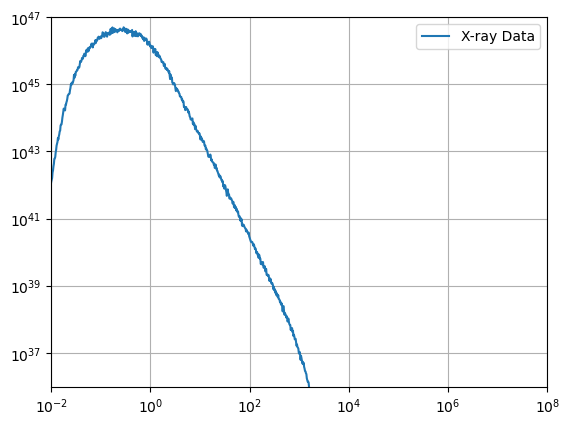

In [58]:
plt.plot(prompt.t, sim_data, label = 'X-ray Data')
plt.xlim([1e-2, 1e8])
plt.ylim([1e36, 1e47])
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.legend()
plt.show()

In [59]:
# Wind-only wrapper

from scripts.const import *
from gemma.utils.units_conversion import*

prompt3 = Prompt(
    components=("wind",),
    sample_gw_parameters=False,
    gw_param_mode="mass",
    output="luminosity",
    default_theta_los_deg=0.0,
)

# CGS-ish magnetar defaults (but with a physical mass)
params = {
    "theta_los": 10.0,              # deg

    "gamma_wind": 50.0,             # close to Wind default g0=50
    "theta_cut_wind": 35.0,         # ~pi/2 (wide wind)

    # these are in your wrapper's parameter list; wind module uses them in Magnetar()
    "collapse_wind": 0,           # False
    "P_0_wind": 1.0e-3,             # s
    "B_p_wind": 1.0e15,             # G
    "R_wind": 1.0e6,                # cm
    "eps_wind": 1.0e-3,             # dimensionless
    "kappa_wind": 1.0,              # cm^2/g

    # IMPORTANT: use grams + cm/s here
    "M_wind": 1.4 * M_sun_cgs,      # g  (physical; replaces 1e45)
    "m_ejecta_dyn_wind": 2.0e31,    # g  (~0.01 Msun)
    "v_ejecta_dyn_wind": 0.3 * c_cgs,  # cm/s

    # not really used by your Wind class as written, but your wrapper expects the key:
    "E_iso_wind": 1.0e48,
}

prompt3.update_model(params, dry_run=False, verbose=True)

# print("t range:", prompt.t[0], "->", prompt.t[-1], "s")
# print("total_X shape:", np.asarray(prompt.total_X).shape)
# print("total_X sample:", np.asarray(prompt.total_X)[:5])


Updating model...
Normalized L0: 2.999079273411071e+52


In [5]:
import numpy as np

# Load data
data = np.load("lc_20k_flux.npz")  # or your flux file
t_grid = data["t_grid"]

In [9]:
len(data['t_grid'])

20000

In [25]:
data['Y'].shape[1]

1000

In [11]:
import numpy as np
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, n_in, n_out, width=512, depth=4, dropout=0.0):
        super().__init__()
        layers = []
        d = n_in
        for _ in range(depth):
            layers += [nn.Linear(d, width), nn.ReLU()]
            if dropout > 0:
                layers += [nn.Dropout(dropout)]
            d = width
        layers += [nn.Linear(d, n_out)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Load data
data = np.load("prompt_dataset_25kmerged.npz")  # or your flux file
t_grid = data["t_grid"]

# Load checkpoint TRAINED WITH DISTANCE AS AN INPUT FEATURE
ckpt = torch.load("emulator.pt", map_location="cpu", weights_only=False)

# IMPORTANT: n_in is now 8 (added distance)
model = MLP(n_in=6, n_out=data['Y'].shape[1])
model.load_state_dict(ckpt["model_state"])
model = model.double()
model.eval()

# stats must be length 8 now
x_mean = ckpt["x_mean"].double()
x_std  = ckpt["x_std"].double()
y_mean = ckpt["y_mean"].double()
y_std  = ckpt["y_std"].double()

def featurize(p):
    # Convert dict -> feature vector in a consistent order
    # (Use the same ordering everywhere.)
    mdyn = np.log10(p["m_dyn_jet"])
    theta_los = p["theta_los"] / 60.0
    m1 = p["mass_1"]
    m2 = p["mass_2"]
    lam = np.log10(p["lambda_2"] + 1.0)
    chi = p["chi_1"]
    return np.array([mdyn, theta_los, m1, m2, lam,chi], dtype=np.float32)

params = {
    # jet knobs
    "m_dyn_jet": 0.072, #Msun

    # viewing angle
    "theta_los": 0.0,         # degrees

    # binary / EOS inputs used in _derive_Eiso_jet
    "mass_1": 3,             # Msun
    "mass_2": 1.2,             # Msun
    "lambda_2": 300.0,         # dimensionless tidal deformability
    "chi_1": 0.8
}

x = torch.from_numpy(featurize(params)[None, :]).double()

# normalize once
x = (x - x_mean) / x_std

with torch.no_grad():
    y_norm = model(x)

# de-normalize output
y_log = y_norm * y_std + y_mean
lc = y_log[0].cpu().numpy()

print("t_grid:", t_grid[:5])
print("lc:", lc[:5])

t_grid: [0.001      0.00102096 0.00104236 0.00106421 0.00108652]
lc: [-4.82301312 -3.17494388 -3.05890731 -1.20340685  0.02537373]


In [5]:
np.log10(1e-40)

np.float64(-40.0)

In [4]:
lc.min()

np.float64(-4.823013116049257)

In [12]:
from prompt_dyn import Prompt

def featurize(p):
    # Convert dict -> feature vector in a consistent order
    # (Use the same ordering everywhere.)
    mdyn = np.log10(p["m_dyn_jet"])
    theta_los = p["theta_los"] / 60.0
    m1 = p["mass_1"]
    m2 = p["mass_2"]
    lam = np.log10(p["lambda_2"] + 1.0)
    chi = p["chi_1"]
    return np.array([mdyn, theta_los, m1, m2, lam,chi], dtype=np.float32)

prompt = Prompt(
    components=("jet",),            # just jet for now
    sample_gw_parameters=False,     # we will pass theta_los
    gw_param_mode="mass",           # so _extract_masses expects mass_1/mass_2
    j_struct="tophat",            # or 1/2/3
    eta_jet=1e-4,
    frac=0.1,
    phi_los_deg=0.0,
    default_theta_los_deg=0.0,
)

prompt.check_print()

params = {
    # jet knobs
    "m_dyn_jet": 0.072, #Msun

    # viewing angle
    "theta_los": 0.0,         # degrees

    # binary / EOS inputs used in _derive_Eiso_jet
    "mass_1": 3,             # Msun
    "mass_2": 1.2,             # Msun
    "lambda_2": 300.0,         # dimensionless tidal deformability
    "chi_1": 0.8
}

import sys
print("CELL START")
sys.stdout.flush()

out = prompt.update_model(params, dry_run=False)

print("CELL END", out)
sys.stdout.flush()

Object OK!
CELL START
Updating model...
eisojet val 2.005033283171048e+51
Jet Constructed Successfully...
CELL END None


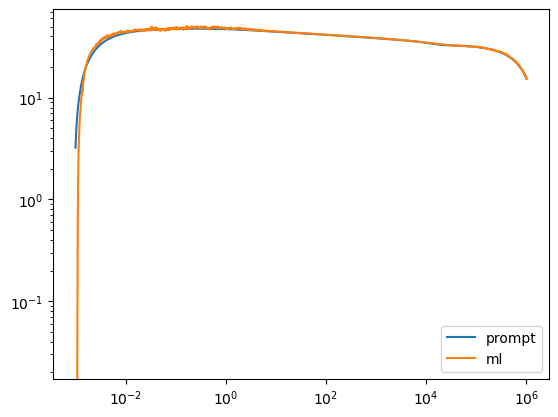

In [18]:
import matplotlib.pyplot as plt
def interp_logt(t_new, t, y, left=0.0, right=0.0):
    # assumes t increasing
    return np.interp(t_new, t, y, left=left, right=right)
y_interp = interp_logt(t_grid, prompt.t, prompt.total_X, left=0.0, right=0.0)
plt.plot(t_grid, np.log10(y_interp), label='prompt')
plt.plot(t_grid, lc, label='ml')

plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

In [57]:
import numpy as np
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, n_in, n_out, width=512, depth=4, dropout=0.0):
        super().__init__()
        layers = []
        d = n_in
        for _ in range(depth):
            layers += [nn.Linear(d, width), nn.ReLU()]
            if dropout > 0:
                layers += [nn.Dropout(dropout)]
            d = width
        layers += [nn.Linear(d, n_out)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Load data
data = np.load("lc_20k_flux.npz")  # or your flux file
t_grid = data["t_grid"]

# Load checkpoint TRAINED WITH DISTANCE AS AN INPUT FEATURE
ckpt = torch.load("promptx_emulator_smooth643.pt", map_location="cpu", weights_only=False)

# IMPORTANT: n_in is now 8 (added distance)
model = MLP(n_in=8, n_out=data['Y'].shape[1])
model.load_state_dict(ckpt["model_state"])
model = model.double()
model.eval()

# stats must be length 8 now
x_mean = ckpt["x_mean"].double()
x_std  = ckpt["x_std"].double()
y_mean = ckpt["y_mean"].double()
y_std  = ckpt["y_std"].double()

def featurize(p, d_mode="log10"):
    """
    d_mode:
      - "raw"   : use d_lum_mpc directly
      - "log10" : use log10(d_lum_mpc)
      - "scaled": use d_lum_mpc/100 (simple scaling)
    """
    gamma = np.log10(p["gamma_jet"])
    theta_c = p["theta_c_jet"] / 90.0
    theta_cut = p["theta_cut_jet"] / 90.0
    theta_los = p["theta_los"] / 90.0
    m1 = p["mass_1"]
    m2 = p["mass_2"]
    lam = np.log10(p["lambda_2"] + 1.0)

    d_mpc = float(p["luminosity_distance"])
    if d_mode == "raw":
        d_feat = d_mpc
    elif d_mode == "scaled":
        d_feat = d_mpc / 100.0
    else:  # "log10"
        d_feat = np.log10(d_mpc)

    return np.array([gamma, theta_c, theta_cut, theta_los, m1, m2, lam, d_feat], dtype=np.float64)

# Example parameters (+ distance in Mpc)
p = {
    "gamma_jet": 100.0,
    "theta_c_jet": 5.0,
    "theta_cut_jet": 35.0,
    "theta_los": 0.0,
    "mass_1": 1.4,
    "mass_2": 1.2,
    "lambda_2": 300.0,
    "luminosity_distance": 50.0,   # <-- NEW
}

x = torch.from_numpy(featurize(p, d_mode="log10")[None, :]).double()

# normalize once
x = (x - x_mean) / x_std

with torch.no_grad():
    y_norm = model(x)

# de-normalize output
y_log = y_norm * y_std + y_mean
lc = y_log[0].cpu().numpy()

print("t_grid:", t_grid[:5])
print("lc:", lc[:5])

t_grid: [0.001      0.00102096 0.00104236 0.00106421 0.00108652]
lc: [-45.10894798 -44.87082124 -43.58013782 -42.57595249 -41.74288158]


In [71]:
import numpy as np
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, n_in, n_out, width=512, depth=4, dropout=0.0):
        super().__init__()
        layers = []
        d = n_in
        for _ in range(depth):
            layers += [nn.Linear(d, width), nn.ReLU()]
            d = width
        layers += [nn.Linear(d, n_out)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

ckpt = torch.load("emulator_lum_log_smooth642.pt", map_location="cpu", weights_only=False)

# read dims from checkpoint
n_in = ckpt["x_mean"].shape[1]
T    = ckpt["t_grid"].numel()
arch = ckpt["arch"]

model = MLP(n_in=n_in, n_out=T, width=arch["width"], depth=arch["depth"], dropout=arch["dropout"]).double()
model.load_state_dict(ckpt["model_state"])
model.eval()

x_mean = ckpt["x_mean"].double()
x_std  = ckpt["x_std"].double()
y_mean = ckpt["y_mean"].double()
y_std  = ckpt["y_std"].double()
t_grid = ckpt["t_grid"].cpu().numpy()
y_floor = float(ckpt["y_floor"])

# build your feature vector to match training (if trained on lum_log, n_in=7)
def featurize_6(p):
    theta_c = p["theta_c_jet"] / 90.0
    theta_cut = p["theta_cut_jet"] / 90.0
    theta_los = p["theta_los"] / 90.0
    m1 = p["mass_1"]
    m2 = p["mass_2"]
    lam = np.log10(p["lambda_2"] + 1.0)
    return np.array([theta_c, theta_cut, theta_los, m1, m2, lam], dtype=np.float64)

p = {
    "theta_c_jet": 5.0,
    "theta_cut_jet": 35.0,
    "theta_los": 0.0,
    "mass_1": 1.4,
    "mass_2": 1.2,
    "lambda_2": 300.0,
}

x = torch.from_numpy(featurize_6(p)[None, :]).double()
x = (x - x_mean) / x_std

with torch.no_grad():
    y_norm = model(x)
y_log = (y_norm * y_std + y_mean)[0].cpu().numpy()
from scipy.signal import savgol_filter
#y_log_smooth = savgol_filter(y_log, window_length=31, polyorder=3)# log10(L + floor)
# F = 10**y_log - y_floor                              # luminosity in linear

print("t_grid[:5] =", t_grid[:5])
print("log10(L+floor)[:5] =", y_log[:5])
print("L[:5] =", L[:5])

t_grid[:5] = [0.001      0.00102096 0.00104236 0.00106421 0.00108652]
log10(L+floor)[:5] = [-3.02694552 -1.92995638 -0.15639441  0.04066873  1.94487842]
L[:5] = [9.80135307e+03 1.24793441e+05 3.53841738e+05 1.27923670e+06
 3.75880440e+07]


In [22]:
# D in Mpc -> cm
MPC_TO_CM = 3.0856775814913673e24
D_cm = (50.0 * MPC_TO_CM)
lc_flux = (10**y_log-y_floor) / (4.0 * np.pi * D_cm * D_cm)
flog = np.log10(4*np.pi)+ 2*np.log10(D_cm)
lc_fluxlog = np.log10(lc_flux+1e-40)

In [26]:
# D in Mpc -> cm
MPC_TO_CM = 3.0856775814913673e24
D_cm = (50.0 * MPC_TO_CM)
F = L / (4.0 * np.pi * D_cm * D_cm)
flog = np.log10(4*np.pi)+ 2*np.log10(D_cm)
Flog = y_log - flog

In [ ]:
plt.plot(t, , label = 'X-ray Data')
plt.xlim([1e-2, 1e8])
plt.ylim([1e36, 1e47])
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.legend()
plt.show()

In [75]:
prompt4 = Prompt(
    components=("jet",),            # just jet for now
    sample_gw_parameters=False,     # we will pass theta_los
    gw_param_mode="mass",           # so _extract_masses expects mass_1/mass_2
    j_struct="tophat",            # or 1/2/3
    eta=1e-4,
    frac=0.1,
    phi_los_deg=0.0,
    default_theta_los_deg=0.0,
    output='luminosity'
)

prompt4.check_print()

params = {
    # jet knobs
    "gamma_jet": 100.0,
    "theta_c_jet": 5.0,        # degrees
    "theta_cut_jet": 35.0,     # degrees

    # viewing angle
    "theta_los": 0.0,         # degrees

    # binary / EOS inputs used in _derive_Eiso_jet
    "mass_1": 1.4,             # Msun
    "mass_2": 1.2,             # Msun
    "lambda_2": 300.0,         # dimensionless tidal deformability
}

import sys
print("CELL START")
sys.stdout.flush()

out = prompt4.update_model(params, dry_run=False)

print("CELL END", out)
sys.stdout.flush()

Object OK!
CELL START
Updating model...
Jet Constructed Successfully...
CELL END None


In [12]:
prompt5 = Prompt(
    components=("jet",),            # just jet for now
    sample_gw_parameters=False,     # we will pass theta_los
    gw_param_mode="mass",           # so _extract_masses expects mass_1/mass_2
    j_struct="tophat",            # or 1/2/3
    eta=1e-4,
    frac=0.1,
    phi_los_deg=0.0,
    default_theta_los_deg=0.0,
    output='flux'
)

prompt5.check_print()

params = {
    # jet knobs
    "gamma_jet": 200.0,
    "theta_c_jet": 5.0,        # degrees
    "theta_cut_jet": 35.0,     # degrees

    # viewing angle
    "theta_los": 0.0,         # degrees

    # binary / EOS inputs used in _derive_Eiso_jet
    "mass_1": 1.4,             # Msun
    "mass_2": 1.2,             # Msun
    "lambda_2": 300.0,         # dimensionless tidal deformability
}

import sys
print("CELL START")
sys.stdout.flush()

out = prompt5.update_model(params, dry_run=False)

print("CELL END", out)
sys.stdout.flush()

Object OK!
CELL START
Updating model...
Jet Constructed Successfully...
CELL END None


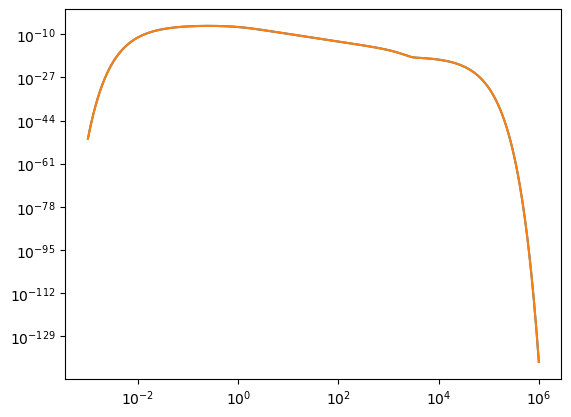

In [9]:
import matplotlib.pyplot as plt

plt.plot(t_grid, prompt4.total_X, label='100')
plt.plot(t_grid, prompt5.total_X, label='200')
plt.yscale('log')
plt.xscale('log')

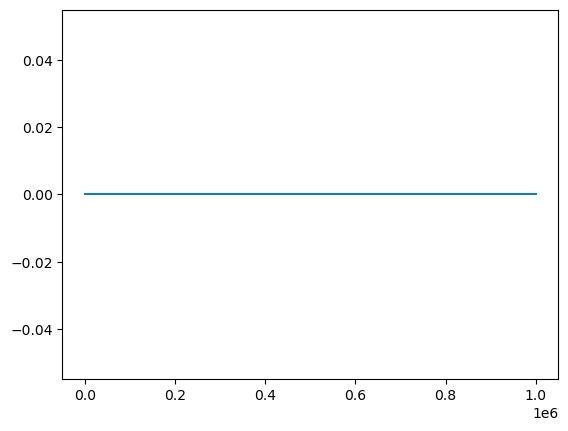

In [10]:
resid = prompt4.total_X-prompt5.total_X
resid /= prompt4.total_X

plt.plot(t_grid, resid)

In [7]:
t_grid = np.logspace(-3, 6, 1000).astype(np.float32)

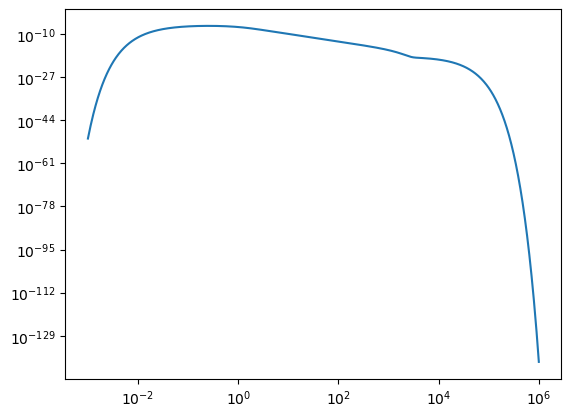

In [30]:
plt.plot(t_grid, prompt4.total_X, label="PromptX")
plt.yscale('log')
plt.xscale('log')

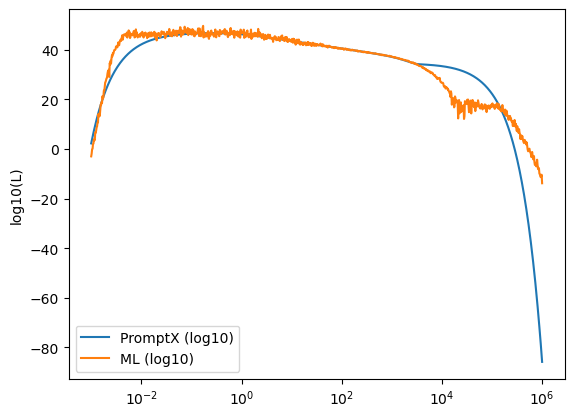

In [73]:
import matplotlib.pyplot as plt

plt.plot(t_grid, np.log10(prompt4.total_X), label="PromptX (log10)")
plt.plot(t_grid, y_log-np.log, label="ML (log10)")
plt.xscale("log")
# plt.yscale('log')
plt.ylabel("log10(L)")
# plt.xlim([1e5, 1e6])
plt.legend()

In [42]:
from scipy.signal import savgol_filter
lc_smooth = savgol_filter(Flog, window_length=31, polyorder=3, mode = 'interp')  # tune window

In [83]:
truth = np.interp(t_grid, prompt4.t, prompt4.total_X, left=0, right=0)

(-15.0, 15.0)

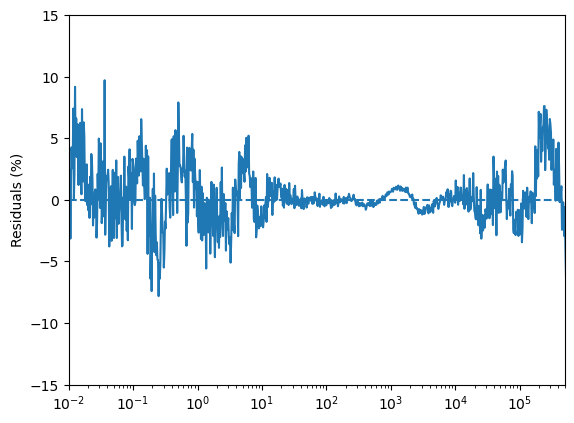

In [101]:
res_log = (np.log10(truth+(1e-40)) - lc)/55
plt.semilogx(t_grid, (10**res_log-1)*100)
plt.axhline(0, ls="--")
plt.ylabel("Residuals (%)")
plt.xlim([1e-2, 5e5])
plt.ylim(-15,15)

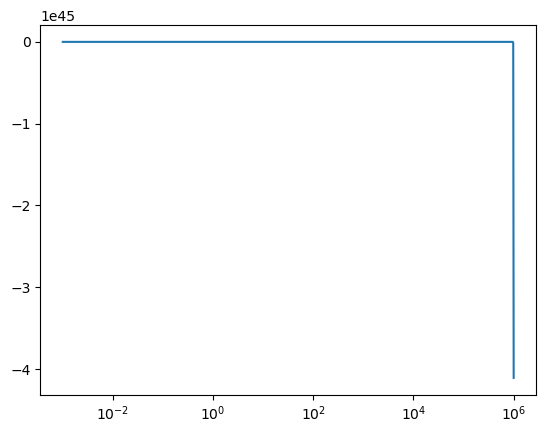

In [102]:
plt.plot(t_grid, (lc_flux-prompt4.total_X)/prompt4.total_X)
plt.xscale('log')

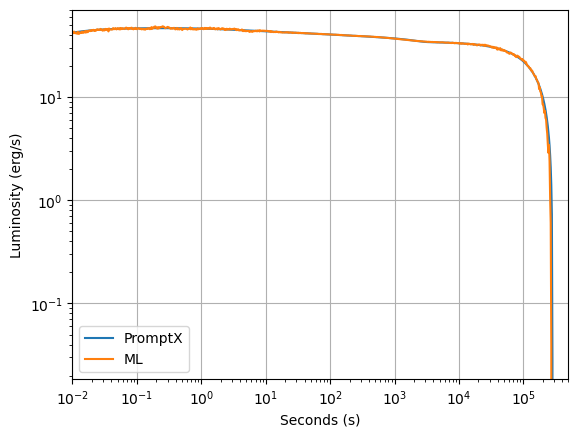

In [104]:
import matplotlib.pyplot as plt

plt.plot(t_grid, np.log10(prompt4.total_X+1e-40), label = 'PromptX')
# plt.plot(prompt4.t, prompt4.total_gamma, label = 'Gamma-Rays')
plt.plot(t_grid, lc, label='ML')
plt.xlim([1e-2, 5e5])
# plt.ylim([1e-11, 2e-4])
plt.ylabel('Luminosity (erg/s)')
plt.xlabel('Seconds (s)')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.legend()
plt.savefig('ML4.png')
plt.show()

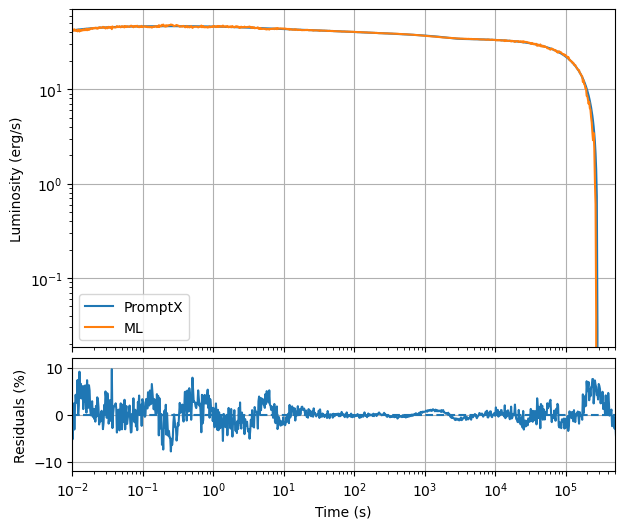

In [131]:
fig = plt.figure(figsize=(7, 6))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])
axr = fig.add_subplot(gs[1], sharex=ax)
ax.tick_params(axis="x", which="both", labelbottom=False)

ax.plot(t_grid, np.log10(prompt4.total_X+1e-40), label = 'PromptX')
ax.plot(t_grid, lc, label='ML')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Luminosity (erg/s)')
ax.legend()
ax.grid()

axr.plot(t_grid, (10**res_log-1)*100)
axr.axhline(0.0, ls='--')
axr.set_xlabel('Time (s)')
axr.set_ylabel('Residuals (%)')
axr.set_xlim(1e-2,5e5)
axr.set_ylim(-12,12)
axr.grid()

plt.savefig('ML5.png')
plt.show()

In [78]:
def interp_logt(t_new, t, y, left=0.0, right=0.0):
    # assumes t increasing
    return np.interp(t_new, t, y, left=left, right=right)

y_itp = interp_logt(t_grid, prompt4.t, prompt4.total_X, left=0.0, right=0.0)

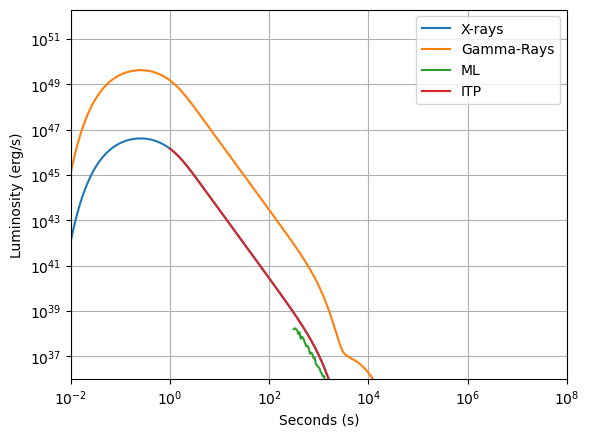

In [79]:
import matplotlib.pyplot as plt

plt.plot(prompt4.t, prompt4.total_X, label = 'X-rays')
plt.plot(prompt4.t, prompt4.total_gamma, label = 'Gamma-Rays')
plt.plot(t_grid, lc, label='ML')
plt.plot(t_grid, y_itp, label ='ITP')
plt.xlim([1e-2, 1e8])
plt.ylim([1e36, 2e52])
plt.ylabel('Luminosity (erg/s)')
plt.xlabel('Seconds (s)')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.legend()
plt.show()